In [1]:
from google.colab import files
uploaded = files.upload()

Saving Sales_April_2019.csv to Sales_April_2019.csv
Saving Sales_August_2019.csv to Sales_August_2019.csv
Saving Sales_December_2019.csv to Sales_December_2019.csv
Saving Sales_February_2019.csv to Sales_February_2019.csv
Saving Sales_January_2019.csv to Sales_January_2019.csv
Saving Sales_July_2019.csv to Sales_July_2019.csv
Saving Sales_June_2019.csv to Sales_June_2019.csv
Saving Sales_March_2019.csv to Sales_March_2019.csv
Saving Sales_May_2019.csv to Sales_May_2019.csv
Saving Sales_November_2019.csv to Sales_November_2019.csv
Saving Sales_October_2019.csv to Sales_October_2019.csv
Saving Sales_September_2019.csv to Sales_September_2019.csv


In [4]:
import pandas as pd

# List all uploaded files manually
files = [
    "Sales_April_2019.csv",
    "Sales_August_2019.csv",
    "Sales_December_2019.csv",
    "Sales_February_2019.csv",
    "Sales_January_2019.csv",
    "Sales_July_2019.csv",
    "Sales_June_2019.csv",
    "Sales_March_2019.csv",
    "Sales_May_2019.csv",
    "Sales_November_2019.csv",
    "Sales_October_2019.csv",
    "Sales_September_2019.csv"
]

all_data = pd.DataFrame()

for file in files:
    df = pd.read_csv(file)
    all_data = pd.concat([all_data, df])

all_data.to_csv("all_data.csv", index=False)

print("Merged Successfully ✅")

Merged Successfully ✅


In [5]:
df = pd.read_csv("all_data.csv")

df = df.dropna(how='all')

df = df[df['Order Date'].str[0:2] != 'Or']

df['Quantity Ordered'] = pd.to_numeric(df['Quantity Ordered'])
df['Price Each'] = pd.to_numeric(df['Price Each'])

In [6]:
df['Sales'] = df['Quantity Ordered'] * df['Price Each']

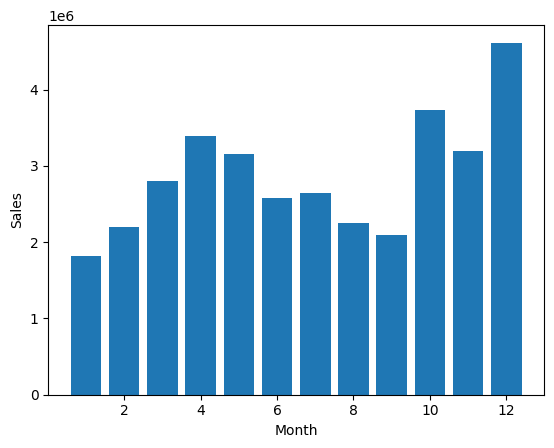

In [7]:
import matplotlib.pyplot as plt

df['Month'] = df['Order Date'].str[0:2].astype('int32')

results = df.groupby('Month').sum()

months = range(1,13)

plt.bar(months, results['Sales'])
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

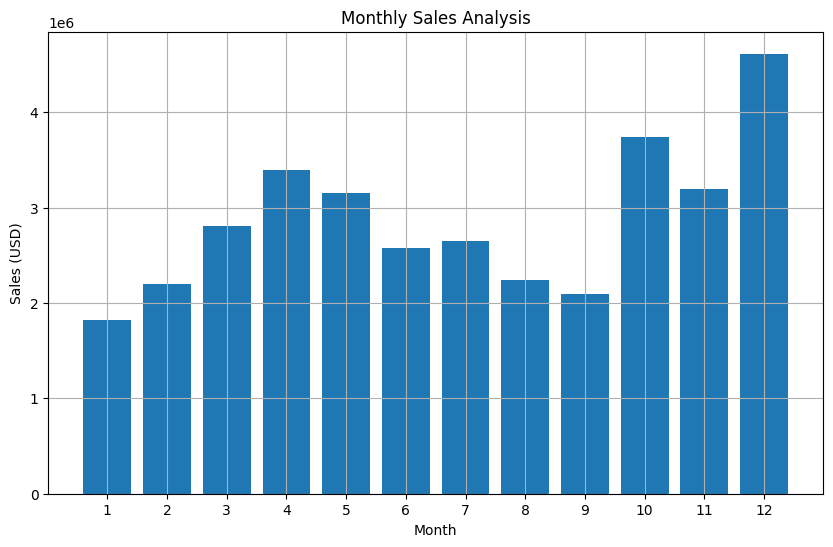

In [8]:
import matplotlib.pyplot as plt

months = range(1,13)

plt.figure(figsize=(10,6))
plt.bar(months, results['Sales'])

plt.xticks(months)
plt.xlabel('Month')
plt.ylabel('Sales (USD)')
plt.title('Monthly Sales Analysis')

plt.grid()

plt.show()

In [9]:
print(results['Sales'])

Month
1     1822256.73
2     2202022.42
3     2807100.38
4     3390670.24
5     3152606.75
6     2577802.26
7     2647775.76
8     2244467.88
9     2097560.13
10    3736726.88
11    3199603.20
12    4613443.34
Name: Sales, dtype: float64


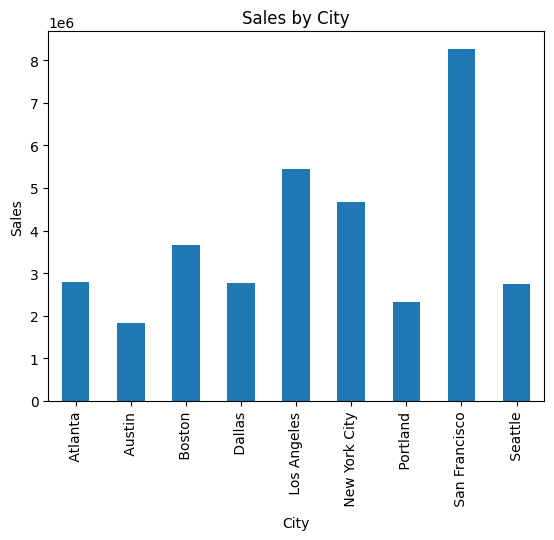

In [10]:
df['City'] = df['Purchase Address'].apply(lambda x: x.split(',')[1])

results_city = df.groupby('City').sum()

results_city['Sales'].plot(kind='bar')

plt.title('Sales by City')
plt.xlabel('City')
plt.ylabel('Sales')
plt.show()

/tmp/ipykernel_12000/2138373515.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Order Date'] = pd.to_datetime(df['Order Date'])


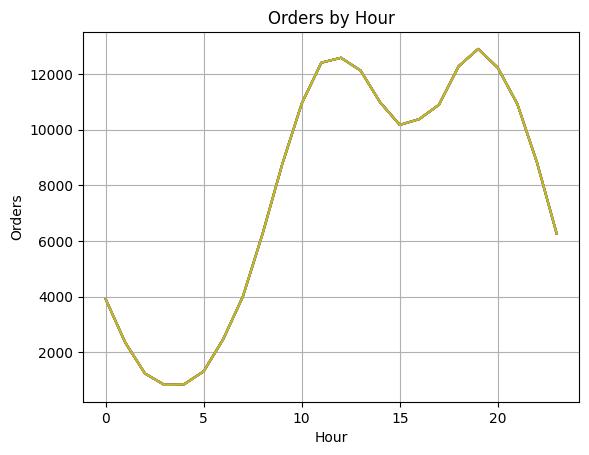

In [11]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Hour'] = df['Order Date'].dt.hour

hours = [hour for hour, df in df.groupby('Hour')]

plt.plot(hours, df.groupby(['Hour']).count())

plt.xlabel('Hour')
plt.ylabel('Orders')
plt.title('Orders by Hour')
plt.grid()

plt.show()

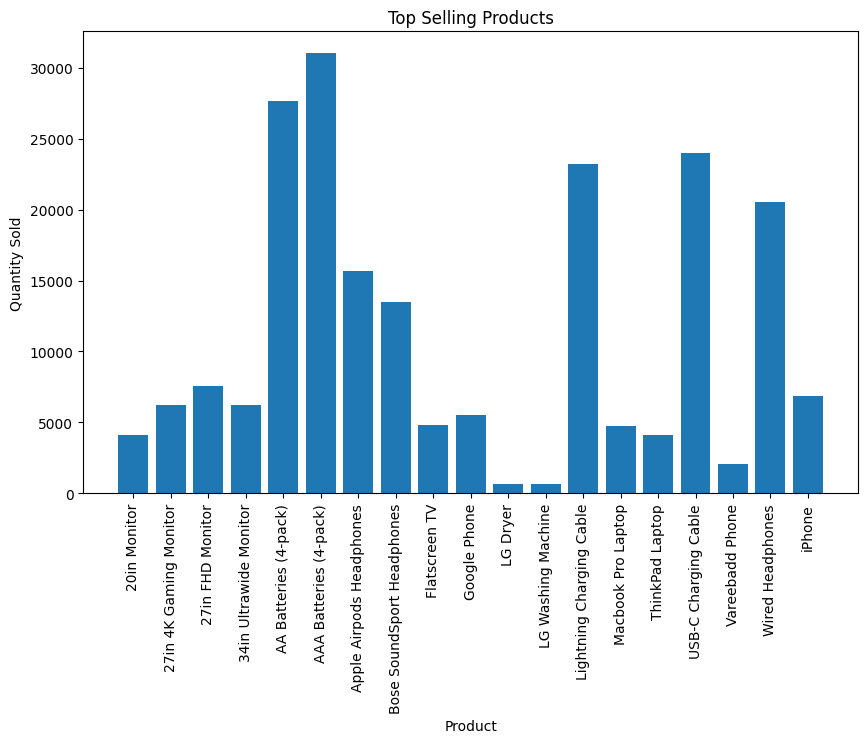

In [13]:
product_group = df.groupby('Product')
quantity_ordered = product_group['Quantity Ordered'].sum()

products = [product for product, df in product_group]

plt.figure(figsize=(10,6))
plt.bar(products, quantity_ordered)
plt.xticks(products, rotation='vertical')

plt.title('Top Selling Products')
plt.xlabel('Product')
plt.ylabel('Quantity Sold')

plt.show()

In [14]:
all_data.to_csv("all_data.csv", index=False)